In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from utils import get_partition_distances

In [2]:
splits = pd.read_csv("./data/3_clustering_folds/split.csv")
save_path = "./images/3_clustering_folds/"
print(splits.head(2))
DIST_PATH = "../data/rnadist_f_all.h5"
dist = pd.read_hdf(DIST_PATH)
dist.head(2)

                          id  fold_number partition
0  16s_B.burgdorferi_domain4            0      test
1            RNaseP_T.roseum            0      test


id,5s_Acholeplasma-laidlawii-1,5s_Acidovorax-temperans-1,tmRNA_Stre.gord._TRW-29390_1-349,tRNA_tdbR00000055-Schizosaccharomyces_pombe-4896-Glu-3UC,srp_List.mono._U15684,5s_Methanothermobacter-thermautotrophicus-6,srp_Vibr.fisc._CP000020,srp_Baci.thur._D11412,grp1_a.I1.m.M.grisea.B2.ND1,5s_Saprospira-grandis-1,...,RNaseP_M.avium,tRNA_tdbR00000521-Bos_taurus-9913-Ini-CAU,grp1_a.I1.e.P.pachydermus.C1.SSU.943,5s_Pseudomonas-stutzeri-2,16s_T.maritima_domain3,5s_Bacillus-cereus-6,srp_Myco.aviu._AE016958,tmRNA_Heli.pylo._AE001503_1-383,5s_Triticum-aestivum-1,5s_Streptomyces-violaceus-1
id,,,,,,,,,,,,,,,,,,,,,
5s_Acholeplasma-laidlawii-1,0.000000,0.130435,0.805158,0.562500,0.799283,0.265625,0.776786,0.756458,0.782456,0.173554,...,0.763819,0.625000,0.795918,0.150000,0.817734,0.140351,0.696429,0.806789,0.200000,0.216667
5s_Acidovorax-temperans-1,0.130435,0.000000,0.819484,0.591304,0.802867,0.179688,0.747826,0.752768,0.778947,0.132231,...,0.756281,0.652174,0.798469,0.108333,0.815271,0.130435,0.756522,0.814621,0.191667,0.125000


In [3]:
folds = splits.fold_number.unique()
folds.sort()

In [4]:
splits["partition"] = splits["partition"].apply(
    lambda x: "train" if x in ["train", "valid"] else "test"
)
parts = list(splits.partition.unique())

In [5]:
splits.partition.unique()

array(['test', 'train'], dtype=object)

In [6]:
parts = splits.partition.unique()
dfs = {fold : {s: {p: pd.DataFrame() for p in parts} for s in parts} for fold in folds}
for fold in folds:
    for p1 in parts:
        for p2 in parts:
            dfs[fold][p1][p2] = get_partition_distances(dist, splits, fold, p1, p2)
            print(f"Fold {fold} - {p1} vs {p2}: {dfs[fold][p1][p2].shape}")

Fold 0 - test vs test: (387, 387)
Fold 0 - test vs train: (387, 3477)


Fold 0 - train vs test: (3477, 387)
Fold 0 - train vs train: (3477, 3477)
Fold 1 - test vs test: (389, 389)
Fold 1 - test vs train: (389, 3475)
Fold 1 - train vs test: (3475, 389)
Fold 1 - train vs train: (3475, 3475)
Fold 2 - test vs test: (388, 388)
Fold 2 - test vs train: (388, 3476)
Fold 2 - train vs test: (3476, 388)
Fold 2 - train vs train: (3476, 3476)
Fold 3 - test vs test: (389, 389)
Fold 3 - test vs train: (389, 3475)
Fold 3 - train vs test: (3475, 389)
Fold 3 - train vs train: (3475, 3475)
Fold 4 - test vs test: (387, 387)
Fold 4 - test vs train: (387, 3477)
Fold 4 - train vs test: (3477, 387)
Fold 4 - train vs train: (3477, 3477)


In [7]:
stats = {"fold": [], "min": [],"mean": [],"max": [] }
for fold in folds:
    A = dfs[fold]["train"]["test"].values
    stats["fold"].append(fold)
    stats["min"].append(np.nanmin(A))
    stats["mean"].append(np.nanmean(A))
    stats["max"].append(np.nanmax(A))
df_stats = pd.DataFrame(stats)
df_stats

,fold,min,mean,max
0,0,0.0,0.648965,1.321739
1,1,0.0,0.637171,1.406250
2,2,0.0,0.659941,1.373737
3,3,0.0,0.670585,1.321739
4,4,0.0,0.650056,1.373737


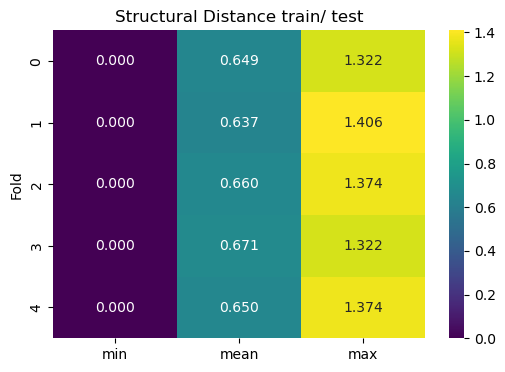

In [8]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df_stats.set_index("fold"),
    annot=True, fmt=".3f",
    cmap="viridis",
    vmin=0, vmax=1.41
)
plt.title("Structural Distance train/ test")
plt.ylabel("Fold")
plt.savefig(save_path+"heatmap_stats.pdf")
plt.show()


<Axes: xlabel='id', ylabel='id'>

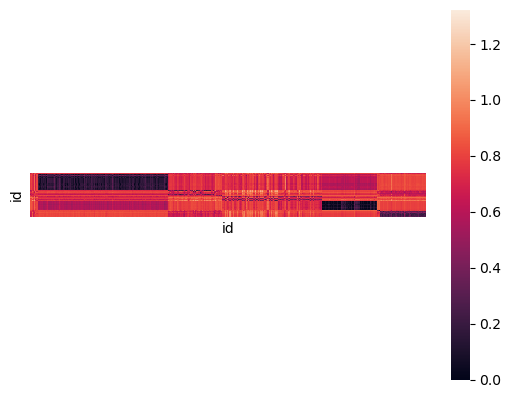

In [9]:
sns.heatmap(data=dfs[0]['test']['train'], square=True,
        xticklabels=False,
        yticklabels=False,)

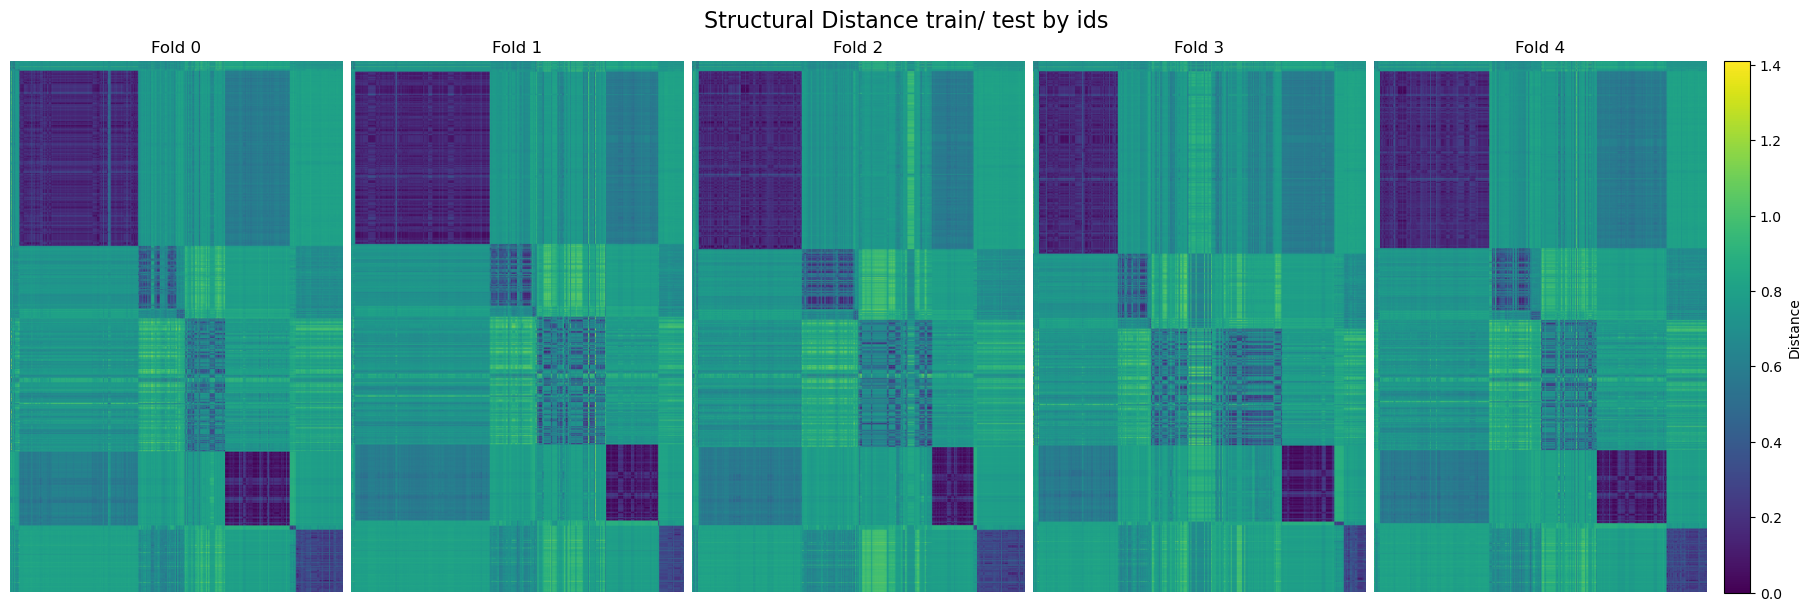

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(18, 6), constrained_layout=True)

vmin, vmax = 0, 1.41  # escala fija
for fold in range(5):
    mat = dfs[fold]['train']['test'].values
    im = axes[fold].imshow(mat, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    axes[fold].set_title(f"Fold {fold}")
    axes[fold].axis('off')  # quita los ticks/labels

# agregar barra de color única
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label("Distance")

plt.suptitle("Structural Distance train/ test by ids", fontsize=16)
plt.savefig(save_path+"heatmap_ids.pdf")
plt.show()


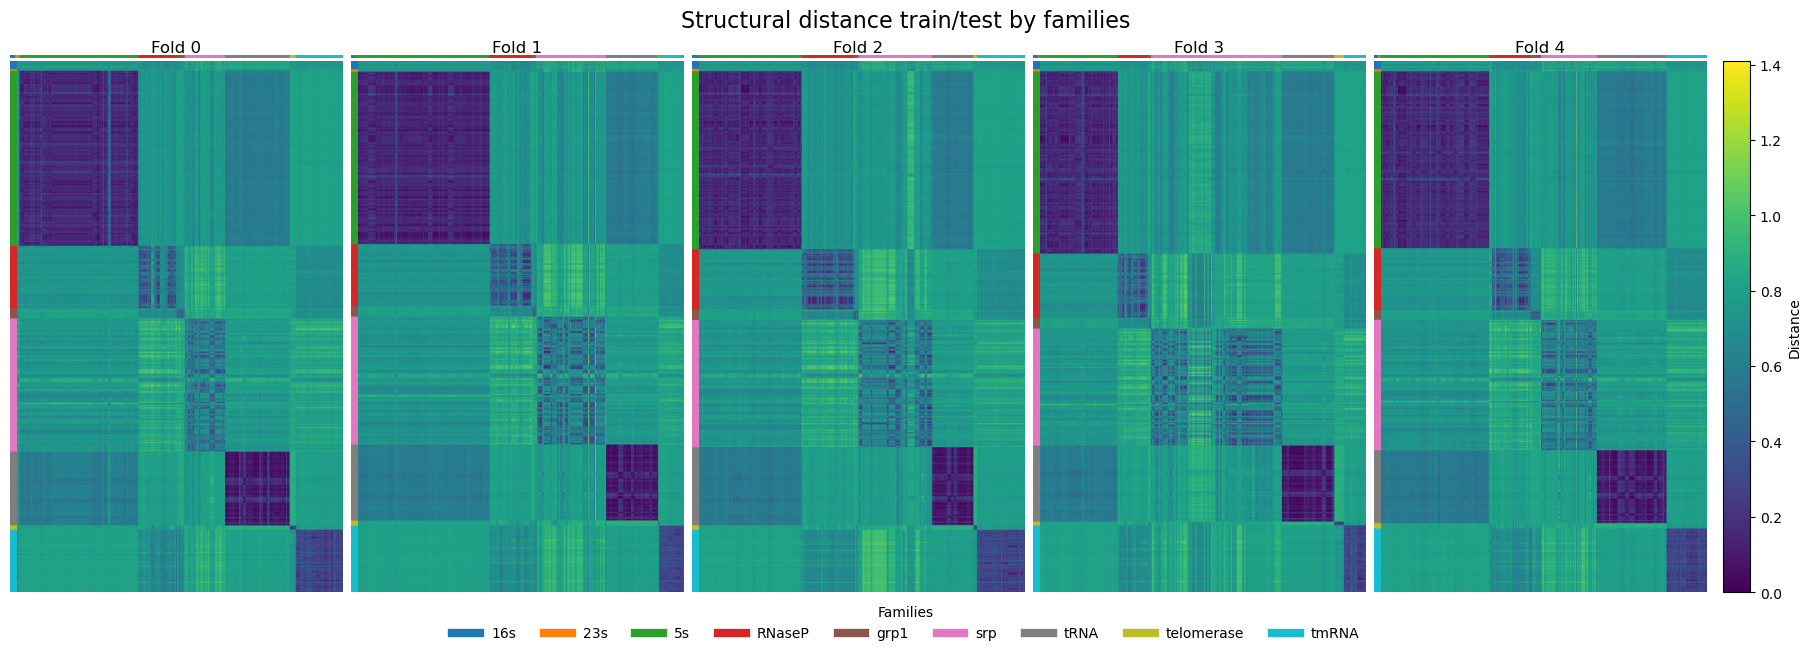

In [11]:
from utils import plot_heatmap_idsxfam
plot_heatmap_idsxfam(dfs, splits, save_path,SAVE=False)

In [11]:
dfs_dists = {}

for fold in folds:
    rows = []
    for part1, dic in dfs[fold].items():
        for part2, mat in dic.items():
            # solo analizamos train/test (part1 != part2)
            if part1 != part2:
                vals = mat.to_numpy().ravel()
                rows.extend({
                    "part1": part1,
                    "part2": part2,
                    "dist": float(v)
                } for v in vals)

    dfs_dists[fold] = pd.DataFrame(rows)

# ejemplo: muestro 5 filas
dfs_dists[0].sample(5)


,part1,part2,dist
454155,test,train,0.692683
61644,test,train,0.759259
287663,test,train,0.621849
2628145,train,test,0.809917
1750417,train,test,0.191667


/tmp/ipykernel_1713697/2061987441.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', n_folds)
/tmp/ipykernel_1713697/2061987441.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


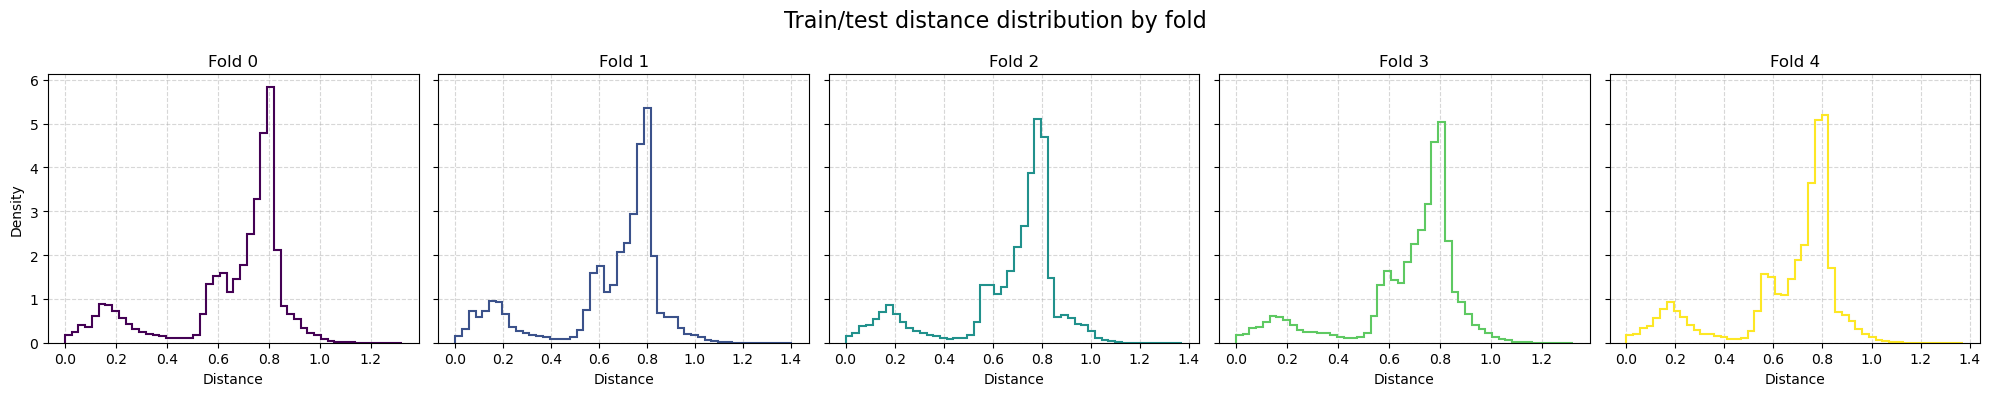

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

n_folds = len(folds)
cmap = cm.get_cmap('viridis', n_folds)
colors = [cmap(i) for i in range(n_folds)]

fig, axes = plt.subplots(1, n_folds, figsize=(20, 4), constrained_layout=True, sharey=True)

for i, fold in enumerate(folds):
    df = dfs_dists[fold]
    axes[i].hist(
        df['dist'],
        bins=50,
        density=True,
        histtype='step',
        color=colors[i],
        linewidth=1.5
    )
    axes[i].set_title(f"Fold {fold}")
    axes[i].set_ylabel("")
    axes[i].set_xlabel("Distance")
    axes[i].grid(True, ls="--", alpha=0.5)

axes[0].set_ylabel("Density")
plt.suptitle("Train/test distance distribution by fold", fontsize=16)
plt.tight_layout()
plt.savefig(save_path+"hist_subplots.pdf")

plt.show()


/tmp/ipykernel_1713697/267434709.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(folds))


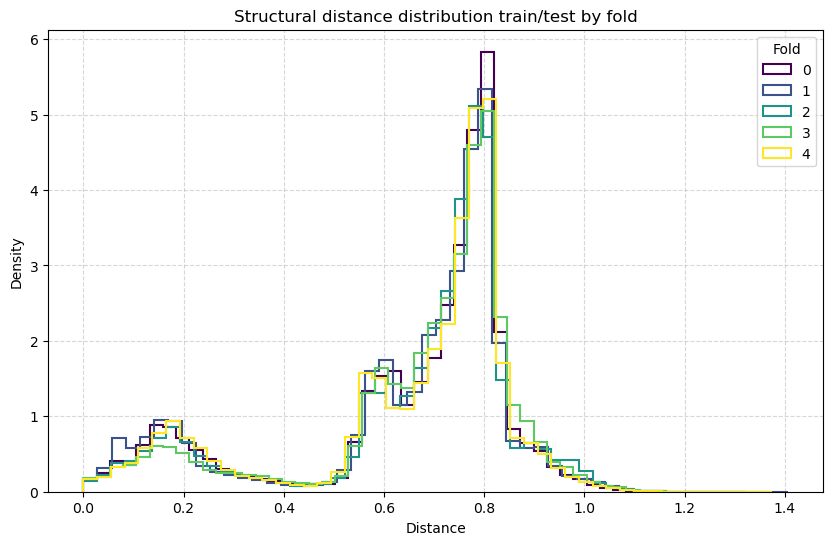

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.figure(figsize=(10, 6))

# Genero colores de la paleta viridis
cmap = cm.get_cmap('viridis', len(folds))
colors = [cmap(i) for i in range(len(folds))]

for i, fold in enumerate(folds):
    df = dfs_dists[fold]
    plt.hist(
        df['dist'],
        bins=50,
        density=True,
        histtype='step',
        color=colors[i],
        linewidth=1.5,
        label=f"{fold}"
    )

plt.title("Structural distance distribution train/test by fold")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.grid(True, ls="--", alpha=0.5)
plt.legend(title="Fold")

plt.savefig(save_path+"hist.pdf")
plt.show()


/tmp/ipykernel_1713697/3730707909.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(folds))


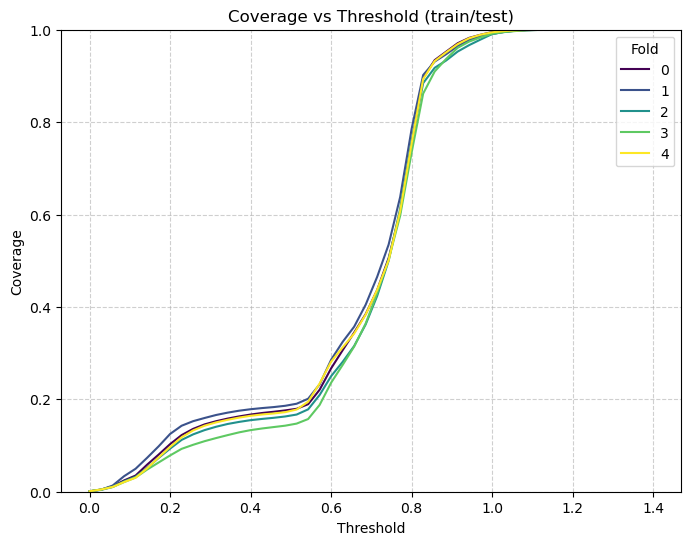

{np.int64(0): 0.17777138657207683, np.int64(1): 0.18808825433226684, np.int64(2): 0.16487504893644786, np.int64(3): 0.1451846646076455, np.int64(4): 0.17476529040226696}


In [14]:
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.linspace(0, 1.4, 50)
cmap = cm.get_cmap('viridis', len(folds))
colors = [cmap(i) for i in range(len(folds))]

plt.figure(figsize=(8, 6))
cover_metric = {}
for i, fold in enumerate(folds):
    mat = dfs[fold]['train']['test']
    vals_dist = mat.values.ravel()
    cover_metric[fold] = (vals_dist <= 0.5).mean().item()
    coverage = [(vals_dist <= t).mean() for t in thresholds]
    plt.plot(
        thresholds,
        coverage,
        label=f"{fold}",
        color=colors[i]
    )


plt.title("Coverage vs Threshold (train/test)")
plt.xlabel("Threshold")
plt.ylabel("Coverage")
plt.grid(True, ls="--", alpha=0.6)
plt.ylim(0, 1)
plt.legend(title="Fold")
plt.savefig(save_path+"coverage.pdf")

plt.show()
print(cover_metric)